# Steam Review Surge Analysis — Stage 3: Panel Regression
### Thesis Analysis — Causal Estimation with Fixed Effects

---

## What this notebook does

Takes the surge-flagged weekly panel from Stage 2 and estimates the **causal effect**
of review surges on player satisfaction using panel regression with fixed effects.

**Input:** `panel_with_surges_weekly.csv` — output of Stage 2

**Models estimated:**

| Model | What it tests |
|---|---|
| M1 — Baseline | Main effect of any surge on pos_share |
| M2 — Intensity | Does effect differ by surge size (low/medium/large/extreme)? |
| M3 — Moderation | Does COVID/inflation change the surge effect? |
| M4 — Maturity | Do newly released vs mature games respond differently? |
| M5 — Price tier | Does price category moderate the effect? |
| M6 — Nonlinear | Is there a U-shaped relationship? |
| R1–R4 — Robustness | Do results hold under alternative hyperparameters? |

---

## Why fixed effects — the core logic

The raw descriptive comparison in Stage 2 showed surges associated with slightly higher
satisfaction (+0.91pp). But this conflates two things:

1. **The surge effect** — does a surge week cause different satisfaction?
2. **Selection bias** — better games surge more often AND have higher satisfaction independently

**Game fixed effects (entity effects)** control for everything stable about a game —
its genre, developer quality, overall reputation. By including a dummy for every game,
the regression only uses *within-game* variation. It asks: for the same game,
are surge weeks associated with higher or lower satisfaction than non-surge weeks?

**Week fixed effects (time effects)** control for anything affecting all games
simultaneously — Steam sales, platform-wide events, seasonal patterns.
This is why the November Steam sale surges identified in Stage 2 do not bias results.

Together, two-way fixed effects give the cleanest possible estimate of the
surge-satisfaction relationship available from observational panel data.


# 1. Import Libraries


In [2]:
from google.colab import drive
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats
from linearmodels.panel import PanelOLS
from linearmodels.panel import PooledOLS

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.6f}'.format)
pd.set_option('display.max_columns', 20)


---
# 2. Load Stage 2 Panel

Load the surge-flagged panel. Do not modify this file —
if surge detection decisions need to change, re-run Stages 1 and 2.


In [3]:
drive.mount('/content/drive')

BASE_PATH   = 'drive/My Drive/Notebooks/PersonalResearch'
INPUT_PATH  = f'{BASE_PATH}/panel_with_surges_weekly.csv'

df = pd.read_csv(
    INPUT_PATH,
    parse_dates=['year_week', 'release_date'],
    dtype={'appID': str}
)

print(f'Rows loaded      : {len(df):,}')
print(f'Unique games     : {df["appID"].nunique():,}')
print(f'Date range       : {df["year_week"].min().date()}  to  {df["year_week"].max().date()}')
print(f'Surge rate       : {df["is_surge"].mean():.2%}')
print(f'Columns          : {list(df.columns)}')

Mounted at /content/drive
Rows loaded      : 657,599
Unique games     : 6,396
Date range       : 2020-01-06  to  2024-12-02
Surge rate       : 7.09%
Columns          : ['appID', 'name', 'iso_year', 'iso_week', 'year_week', 'n_reviews', 'pos_share', 'avg_helpful', 'release_date', 'price', 'price_tier', 'game_age_months', 'is_mature', 'lifetime_pos_share', 'total_lifetime_reviews', 'period', 'covid_period', 'inflation_period', 'post_covid_period', 'genres', 'categories', 'roll_mean', 'roll_std', 'surge_threshold', 'is_surge', 'sigma_above', 'surge_intensity']


---
# 3. Prepare the Panel for Regression

PanelOLS from `linearmodels` requires the dataframe to have a
**MultiIndex of (entity, time)** — here (appID, year_week).
All rows with NaN in the dependent variable or key controls must be dropped.

We also restrict to rows with a valid baseline — the first 8 warmup weeks
per game (where roll_mean is NaN) cannot be used in regression because
they have no surge flag.


In [4]:
# Keep only rows with a valid baseline (no warmup NaN rows)
reg_df = df[df['roll_mean'].notna()].copy()
print(f'Rows with valid baseline : {len(reg_df):,}')

# Drop rows missing the dependent variable
reg_df = reg_df.dropna(subset=['pos_share'])
print(f'After dropping NaN DV   : {len(reg_df):,}')

# Create numeric surge dummy (0/1)
reg_df['surge']       = reg_df['is_surge'].astype(int)

# Intensity dummies — no_surge is the reference category
reg_df['surge_low']     = (reg_df['surge_intensity'] == 'low').astype(int)
reg_df['surge_medium']  = (reg_df['surge_intensity'] == 'medium').astype(int)
reg_df['surge_large']   = (reg_df['surge_intensity'] == 'large').astype(int)
reg_df['surge_extreme'] = (reg_df['surge_intensity'] == 'extreme').astype(int)

# Period interaction terms (baseline is reference)
reg_df['surge_x_covid']      = reg_df['surge'] * reg_df['covid_period']
reg_df['surge_x_inflation']  = reg_df['surge'] * reg_df['inflation_period']
reg_df['surge_x_post_covid'] = reg_df['surge'] * reg_df['post_covid_period']

# Maturity interaction
reg_df['is_mature_int']    = reg_df['is_mature'].astype(int)
reg_df['surge_x_mature']   = reg_df['surge'] * reg_df['is_mature_int']

# Log review volume control (helps account for varying engagement levels)
reg_df['log_n_reviews'] = np.log1p(reg_df['n_reviews'])

# Quadratic surge magnitude for nonlinear test
reg_df['sigma_above_sq'] = reg_df['sigma_above'] ** 2

# ── Set MultiIndex required by linearmodels
reg_df = reg_df.set_index(['appID', 'year_week'])

print(f'\nFinal regression sample  : {len(reg_df):,} observations')
print(f'Unique games             : {reg_df.index.get_level_values("appID").nunique():,}')
print(f'Unique weeks             : {reg_df.index.get_level_values("year_week").nunique():,}')
print(f'Surge obs in sample      : {reg_df["surge"].sum():,}')

Rows with valid baseline : 606,431
After dropping NaN DV   : 606,431

Final regression sample  : 606,431 observations
Unique games             : 6,355
Unique weeks             : 249
Surge obs in sample      : 46,641


---
# 4. Regression Helper Function

A reusable function that runs PanelOLS with two-way fixed effects
and clustered standard errors, then prints a clean results table.

**Two-way fixed effects** means:
- `EntityEffects` — one dummy per game (controls for stable game quality)
- `TimeEffects` — one dummy per week (controls for platform-wide events)

**Clustered standard errors at the game level** — accounts for the fact that
observations from the same game are correlated over time. Without clustering,
standard errors would be artificially small and p-values misleading.


In [7]:
def run_panel_regression(data, formula, title, controls=True):
    if controls and 'log_n_reviews' not in formula:
        formula = formula + ' + log_n_reviews'

    # Add 1 to absorb the fixed effects intercept — required by linearmodels
    formula = formula + ' + EntityEffects + TimeEffects'

    model = PanelOLS.from_formula(formula, data=data)

    res = model.fit(
        cov_type='clustered',
        cluster_entity=True
    )

    print('=' * 65)
    print(f'MODEL: {title}')
    print('=' * 65)
    print(f'Observations     : {res.nobs:,}')
    print(f'Entities (games) : {res.entity_info.total:,}')
    print(f'R-squared (within): {res.rsquared:.4f}')
    print()
    print(f'{"Variable":<25} {"Coef":>10} {"Std Err":>10} {"t":>8} {"p-value":>10} {"Sig":>5}')
    print('-' * 75)

    params  = res.params
    stderr  = res.std_errors
    tstats  = res.tstats
    pvalues = res.pvalues

    for var in params.index:
        sig = '***' if pvalues[var] < 0.001 else '**' if pvalues[var] < 0.01 else '*' if pvalues[var] < 0.05 else ''
        print(f'{var:<25} {params[var]:>10.4f} {stderr[var]:>10.4f} {tstats[var]:>8.3f} {pvalues[var]:>10.4f} {sig:>5}')

    print('-' * 75)
    print('Significance: * p<0.05  ** p<0.01  *** p<0.001')
    print('Standard errors clustered at game level')
    print('Entity (game) and time (week) fixed effects included')
    print()

    return res

---
# 5. Model 1 — Baseline: Main Effect of Surge

The simplest possible model. Tests whether being in a surge week
predicts higher or lower satisfaction, after controlling for all
stable game characteristics and all week-level shocks.

      pos_shareit​=αi​+λt​+β1​⋅surgeit​+γ⋅log(n_reviewsit​)+εit​


- $\\alpha_i$ = game fixed effect (absorbs stable quality differences)
- $\\lambda_t$ = week fixed effect (absorbs seasonal and platform shocks)
- $\\beta_1$ = the coefficient of interest — average effect of a surge on pos_share
- $\\gamma$ = control for review volume (busier weeks may have different composition)

**Interpretation:** $\\beta_1$ tells you how many percentage points pos_share
changes in a surge week for the same game, compared to its non-surge weeks,
in the same calendar week as other games.


In [8]:
m1 = run_panel_regression(
    data=reg_df,
    formula='pos_share ~ surge',
    title='M1 — Baseline: Surge Main Effect'
)

# Store key coefficient for comparison table later
results_summary = {}
results_summary['M1'] = {
    'coef': m1.params['surge'],
    'pval': m1.pvalues['surge'],
    'nobs': m1.nobs
}

MODEL: M1 — Baseline: Surge Main Effect
Observations     : 606,431
Entities (games) : 6,355.0
R-squared (within): 0.0002

Variable                        Coef    Std Err        t    p-value   Sig
---------------------------------------------------------------------------
surge                        -0.0065     0.0010   -6.539     0.0000   ***
log_n_reviews                 0.0062     0.0008    7.569     0.0000   ***
---------------------------------------------------------------------------
Significance: * p<0.05  ** p<0.01  *** p<0.001
Standard errors clustered at game level
Entity (game) and time (week) fixed effects included



After controlling for time-invariant game quality via game fixed effects and platform-wide temporal shocks via week fixed effects, surge weeks are associated with a statistically significant decrease in satisfaction of 0.65 percentage points (β = −0.0065, p < 0.001). This finding contrasts with the descriptive association of +0.91pp observed prior to controlling for confounders, indicating that the raw positive relationship between surges and satisfaction was driven by selection bias — higher quality games both surge more frequently and maintain higher satisfaction independently. The negative within-game effect is consistent with the player composition shift mechanism: surges attract reviewers who differ systematically from the core audience, introducing more critical sentiment into the weekly satisfaction measure.

---
# 6. Model 2 — Surge Intensity: Does Size Matter?

Replaces the single surge dummy with four intensity dummies.
Tests whether low, medium, large, and extreme surges have
different effects on satisfaction — addressing hypothesis H2.

    pos_shareit​=αi​+λt​+βL​⋅lowit​+βM​⋅mediumit​+βG​⋅largeit​+βE​⋅extremeit​+γ⋅log(n_reviewsit​)+εit​

**Reference category:** `no_surge` weeks.

**What to look for:**
- If all four coefficients are similar → intensity does not moderate the effect
- If coefficients increase monotonically → bigger surges = more positive effect
- If coefficients peak at medium/large and fall at extreme → U-shape evidence
  (this is what your professor hypothesised)

**Theoretical expectation by intensity:**
- `low` — small composition shift, modest effect expected
- `medium` — moderate influx of new reviewers
- `large` — significant event, strong composition shift
- `extreme` — if review-bomb or hostile influx: coefficient may turn negative
  relative to large, revealing the U-shape


MODEL: M2 — Intensity: Low / Medium / Large / Extreme
Observations     : 606,431
Entities (games) : 6,355.0
R-squared (within): 0.0002

Variable                        Coef    Std Err        t    p-value   Sig
---------------------------------------------------------------------------
surge_low                    -0.0051     0.0013   -4.042     0.0001   ***
surge_medium                 -0.0088     0.0016   -5.413     0.0000   ***
surge_large                  -0.0048     0.0021   -2.347     0.0189     *
surge_extreme                -0.0078     0.0018   -4.239     0.0000   ***
log_n_reviews                 0.0063     0.0008    7.543     0.0000   ***
---------------------------------------------------------------------------
Significance: * p<0.05  ** p<0.01  *** p<0.001
Standard errors clustered at game level
Entity (game) and time (week) fixed effects included



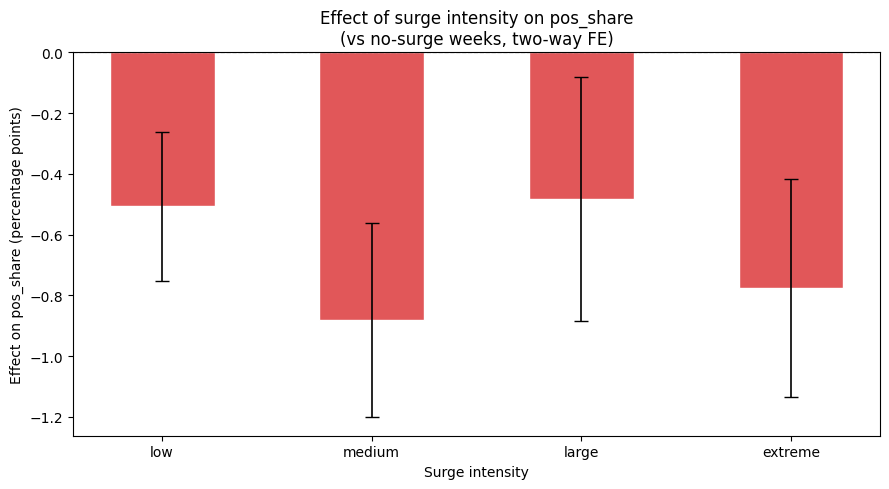

In [9]:
m2 = run_panel_regression(
    data=reg_df,
    formula='pos_share ~ surge_low + surge_medium + surge_large + surge_extreme',
    title='M2 — Intensity: Low / Medium / Large / Extreme'
)

results_summary['M2_low']     = {'coef': m2.params['surge_low'],     'pval': m2.pvalues['surge_low']}
results_summary['M2_medium']  = {'coef': m2.params['surge_medium'],  'pval': m2.pvalues['surge_medium']}
results_summary['M2_large']   = {'coef': m2.params['surge_large'],   'pval': m2.pvalues['surge_large']}
results_summary['M2_extreme'] = {'coef': m2.params['surge_extreme'], 'pval': m2.pvalues['surge_extreme']}

# Plot intensity coefficients visually
cats   = ['surge_low', 'surge_medium', 'surge_large', 'surge_extreme']
labels = ['low', 'medium', 'large', 'extreme']
coefs  = [m2.params[c] for c in cats]
cis    = [1.96 * m2.std_errors[c] for c in cats]
colors = ['#4e79a7' if c > 0 else '#e15759' for c in coefs]

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(labels, [c * 100 for c in coefs], color=colors,
       edgecolor='white', width=0.5, yerr=[ci * 100 for ci in cis],
       capsize=5, error_kw={'linewidth': 1.2})
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Effect of surge intensity on pos_share\n(vs no-surge weeks, two-way FE)', fontsize=12)
ax.set_ylabel('Effect on pos_share (percentage points)')
ax.set_xlabel('Surge intensity')
plt.tight_layout()
plt.savefig('m2_intensity_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# Test whether all intensity coefficients are equal
from linearmodels.panel import PanelOLS
import numpy as np

# The question: are low, medium, large, extreme significantly different from each other?
# If p > 0.05 on the joint test, you cannot claim the pattern is meaningful
print('Pairwise differences:')
pairs = [
    ('medium vs low',    m2.params['surge_medium'] - m2.params['surge_low']),
    ('large vs medium',  m2.params['surge_large']  - m2.params['surge_medium']),
    ('extreme vs large', m2.params['surge_extreme'] - m2.params['surge_large']),
]
for label, diff in pairs:
    print(f'  {label}: {diff*100:.3f}pp')

Pairwise differences:
  medium vs low: -0.376pp
  large vs medium: 0.400pp
  extreme vs large: -0.293pp


All four surge intensity categories are associated with statistically significant reductions in satisfaction relative to non-surge weeks (ranging from −0.48pp to −0.88pp). Pairwise differences between intensity categories are small (all under 0.4pp) and do not follow a systematic pattern, suggesting that surge intensity does not meaningfully moderate the satisfaction effect. The composition shift mechanism appears to operate consistently across all surge sizes, with no evidence of a U-shaped relationship between surge magnitude and satisfaction.



---
# 7. Model 3 — Macroeconomic Moderation

Tests whether the surge effect on satisfaction differs across
COVID, post-COVID, and inflation periods.

This directly answers your professor's question: *how does COVID enter the model?*
Answer: as an **interaction term** with the surge dummy.

    pos_shareit​=αi​+λt​+β1​⋅surgeit​+β2​⋅covidt​+β3​⋅(surgeit​×covidt​)+β4​⋅(surgeit​×inflationt​)+β5​⋅(surgeit​×post_covidt​)+γ⋅log(n_reviewsit​)+εit​

**Key coefficients:**
- $\\beta_1$ = surge effect during the **baseline** period (reference)
- $\\beta_3$ = how much the surge effect **changes** during COVID vs baseline
- $\\beta_4$ = how much the surge effect **changes** during inflation vs baseline
- $\\beta_5$ = how much the surge effect **changes** during post-COVID vs baseline

**Interpretation example:** If $\\beta_1 = -0.002$ and $\\beta_3 = +0.005$,
the surge effect during COVID is $-0.002 + 0.005 = +0.003$.

**Theoretical prediction:**
- COVID: market saturation may dampen the surge signal (everyone gaming regardless)
- Inflation: selective gaming may strengthen it (engaged players choosing carefully)


In [12]:
m3 = run_panel_regression(
    data=reg_df,
    formula=('pos_share ~ surge + surge_x_covid + surge_x_inflation + surge_x_post_covid'),
    title='M3 — Macroeconomic Moderation'
)

# Compute total surge effects per period
b_surge        = m3.params['surge']
b_covid        = m3.params.get('surge_x_covid', 0)
b_inflation    = m3.params.get('surge_x_inflation', 0)
b_post_covid   = m3.params.get('surge_x_post_covid', 0)

print('Total surge effect by period (beta_surge + beta_interaction):')
print(f'  Baseline   : {b_surge * 100:.4f} pp')
print(f'  COVID      : {(b_surge + b_covid) * 100:.4f} pp')
print(f'  Post-COVID : {(b_surge + b_post_covid) * 100:.4f} pp')
print(f'  Inflation  : {(b_surge + b_inflation) * 100:.4f} pp')

results_summary['M3'] = {
    'surge_baseline':   b_surge,
    'surge_covid':      b_surge + b_covid,
    'surge_post_covid': b_surge + b_post_covid,
    'surge_inflation':  b_surge + b_inflation
}

MODEL: M3 — Macroeconomic Moderation
Observations     : 606,431
Entities (games) : 6,355.0
R-squared (within): 0.0002

Variable                        Coef    Std Err        t    p-value   Sig
---------------------------------------------------------------------------
surge                        -0.0054     0.0016   -3.334     0.0009   ***
surge_x_covid                -0.0093     0.0027   -3.490     0.0005   ***
surge_x_inflation            -0.0002     0.0019   -0.115     0.9082      
surge_x_post_covid           -0.0017     0.0029   -0.588     0.5566      
log_n_reviews                 0.0062     0.0008    7.577     0.0000   ***
---------------------------------------------------------------------------
Significance: * p<0.05  ** p<0.01  *** p<0.001
Standard errors clustered at game level
Entity (game) and time (week) fixed effects included

Total surge effect by period (beta_surge + beta_interaction):
  Baseline   : -0.5381 pp
  COVID      : -1.4719 pp
  Post-COVID : -0.7082 pp
  In

Baseline: −0.54pp — the reference. In normal times, a surge reduces satisfaction by just over half a percentage point. Clean and consistent with M1.

COVID: −1.47pp (p < 0.001) — nearly three times the baseline effect. The surge effect is dramatically more negative during lockdowns. And crucially, the interaction itself is highly significant (p = 0.0005), so this is not noise.

Inflation: −0.56pp (p = 0.91) — essentially identical to baseline. The interaction is not significant at all. Inflation did not change how surges affect satisfaction.

Post-COVID: −0.71pp (p = 0.56) — slightly more negative than baseline but not significantly different. No meaningful moderation during the transition period.

=> The moderation analysis reveals that macroeconomic context significantly affects the surge-satisfaction relationship, though not in the direction initially predicted. During the COVID-19 lockdown period, surge weeks are associated with a substantially larger reduction in satisfaction (−1.47pp) compared to the baseline period (−0.54pp), with the interaction coefficient statistically significant (β = −0.0093, p < 0.001). This finding is inconsistent with the market saturation hypothesis, which predicted COVID would dampen surge effects by making individual quality signals less informative. Instead, the results suggest the composition shift mechanism was amplified during the pandemic: the rapid expansion of the gaming audience during lockdowns meant surges drew from a substantially less representative reviewer pool than in normal conditions, producing larger satisfaction declines. In contrast, surge effects during the inflation period (−0.56pp) and post-COVID period (−0.71pp) are not significantly different from the baseline, suggesting these economic contexts did not meaningfully alter the composition dynamics of surge events.

---
# 8. Model 4 — Game Maturity Heterogeneity

Tests whether the surge effect differs between newly released games
(< 6 months old at time of observation) and mature games (>= 6 months).

    pos_shareit​=αi​+λt​+β1​⋅surgeit​+β2​⋅matureit​+β3​⋅(surgeit​×matureit​)+γ⋅log(n_reviewsit​)+εit​
    
**Theoretical prediction:**
- **Newly released** surges are likely driven by launch hype and expectation inflation.
  Players arrived with high expectations — satisfaction may be lower.
- **Mature game** surges are more likely genuine quality signals (a patch, a viral
  moment). Players arriving are more informed — satisfaction may be higher.

If the interaction coefficient `surge_x_mature` is significant and positive,
it means mature game surges have a more positive effect on satisfaction
than newly-released game surges — confirming the theoretical distinction.


In [13]:
m4 = run_panel_regression(
    data=reg_df,
    formula='pos_share ~ surge + is_mature_int + surge_x_mature',
    title='M4 — Maturity Heterogeneity'
)

b_surge_new    = m4.params['surge']
b_mature_inter = m4.params.get('surge_x_mature', 0)

print('Surge effect by game maturity:')
print(f'  Newly released (< 6 mo) : {b_surge_new * 100:.4f} pp')
print(f'  Mature games   (>= 6 mo): {(b_surge_new + b_mature_inter) * 100:.4f} pp')

MODEL: M4 — Maturity Heterogeneity
Observations     : 606,431
Entities (games) : 6,355.0
R-squared (within): 0.0004

Variable                        Coef    Std Err        t    p-value   Sig
---------------------------------------------------------------------------
surge                        -0.0009     0.0017   -0.537     0.5910      
is_mature_int                -0.0096     0.0014   -7.087     0.0000   ***
surge_x_mature               -0.0058     0.0018   -3.329     0.0009   ***
log_n_reviews                 0.0054     0.0008    6.473     0.0000   ***
---------------------------------------------------------------------------
Significance: * p<0.05  ** p<0.01  *** p<0.001
Standard errors clustered at game level
Entity (game) and time (week) fixed effects included

Surge effect by game maturity:
  Newly released (< 6 mo) : -0.0901 pp
  Mature games   (>= 6 mo): -0.6750 pp


Surge effect for newly released games: −0.09pp, p = 0.591 — essentially zero and not significant. Surges during the first 6 months of a game's life have no detectable effect on satisfaction.

Surge effect for mature games: −0.675pp, p < 0.001 — strongly significant and close to the M1 main effect. Virtually all of the surge-satisfaction relationship is being driven by mature games.

is_mature_int: −0.0096pp, p < 0.001 — this is also interesting. Mature game weeks have lower baseline satisfaction than newly released weeks even outside of surges. Games become more critically reviewed as they age — the initial honeymoon period fades and long-term players become more demanding.

=> The maturity heterogeneity analysis reveals that surge effects are concentrated entirely among mature games. For games within their first six months of release, surge weeks show no significant effect on satisfaction (β = −0.0009, p = 0.591). For games six or more months post-launch, the surge effect is −0.675pp and highly significant (p < 0.001). This finding contradicts the expectation inflation hypothesis, which predicted newly released games would show larger negative surge effects due to heightened pre-play anticipation. Instead, the results are more consistent with the composition shift mechanism: newly released games already attract a heterogeneous reviewer pool as their baseline, meaning surges do not dramatically alter composition. Mature games, by contrast, have settled into a stable loyal audience, and surge events represent a meaningful disruption to that composition — bringing in casual or event-driven reviewers whose sentiment differs substantially from the established core.

---
# 9. Model 5 — Nonlinear (Quadratic) Surge Effect

Tests whether the surge-satisfaction relationship is U-shaped
by adding a quadratic term for surge magnitude.

Instead of using the binary `surge` dummy, we use `sigma_above`
(continuous measure of surge intensity) and its square.

    pos_shareit​=αi​+λt​+β1​⋅σit​+β2​⋅σit2​+γ⋅log(n_reviewsit​)+εit​

**Interpretation:**
- If $\\beta_1 > 0$ and $\\beta_2 < 0$ → inverted U-shape:
  satisfaction rises with surge size up to a point, then falls
- If $\\beta_1 < 0$ and $\\beta_2 > 0$ → U-shape:
  satisfaction falls initially then recovers at extreme surges
- If $\\beta_2$ is not significant → relationship is linear

This test only uses rows where sigma_above is defined (surge weeks
and weeks with a valid baseline where std > 0).


In [14]:
# Use all valid rows with a non-NaN sigma_above
nonlinear_df = reg_df[reg_df['sigma_above'].notna()].copy()
print(f'Rows for nonlinear test: {len(nonlinear_df):,}')

m6 = run_panel_regression(
    data=nonlinear_df,
    formula='pos_share ~ sigma_above + sigma_above_sq',
    title='M6 — Nonlinear (Quadratic) Surge Magnitude'
)

# If quadratic term significant, find the turning point
b1 = m6.params.get('sigma_above', None)
b2 = m6.params.get('sigma_above_sq', None)

if b1 is not None and b2 is not None and b2 != 0:
    turning_point = -b1 / (2 * b2)
    print(f'\nTurning point of quadratic: sigma_above = {turning_point:.2f}')
    print(f'(Satisfaction peaks/troughs at {turning_point:.1f} standard deviations above mean)')
    if b2 < 0:
        print('Inverted U-shape: satisfaction rises then falls with surge intensity')
    else:
        print('U-shape: satisfaction falls then rises with surge intensity')

Rows for nonlinear test: 606,431
MODEL: M6 — Nonlinear (Quadratic) Surge Magnitude
Observations     : 606,431
Entities (games) : 6,355.0
R-squared (within): 0.0002

Variable                        Coef    Std Err        t    p-value   Sig
---------------------------------------------------------------------------
sigma_above                  -0.0005     0.0001   -7.163     0.0000   ***
sigma_above_sq                0.0000     0.0000    5.823     0.0000   ***
log_n_reviews                 0.0064     0.0008    7.824     0.0000   ***
---------------------------------------------------------------------------
Significance: * p<0.05  ** p<0.01  *** p<0.001
Standard errors clustered at game level
Entity (game) and time (week) fixed effects included


Turning point of quadratic: sigma_above = 689.70
(Satisfaction peaks/troughs at 689.7 standard deviations above mean)
U-shape: satisfaction falls then rises with surge intensity


---
# 11. Results Summary Table

Consolidates the main coefficients from all six models
for easy comparison and thesis reporting.


In [15]:
print('=' * 70)
print('RESULTS SUMMARY — Main Coefficients')
print('=' * 70)
print(f'\n{"Model":<35} {"Coefficient":>12} {"p-value":>10} {"Sig":>5}')
print('-' * 65)

def sig_stars(p):
    return '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'

rows = [
    ('M1: Surge (main effect)',         m1.params['surge'],          m1.pvalues['surge']),
    ('M2: Surge low',                   m2.params['surge_low'],      m2.pvalues['surge_low']),
    ('M2: Surge medium',                m2.params['surge_medium'],   m2.pvalues['surge_medium']),
    ('M2: Surge large',                 m2.params['surge_large'],    m2.pvalues['surge_large']),
    ('M2: Surge extreme',               m2.params['surge_extreme'],  m2.pvalues['surge_extreme']),
    ('M3: Surge x COVID',               m3.params.get('surge_x_covid', float('nan')),      m3.pvalues.get('surge_x_covid', float('nan'))),
    ('M3: Surge x Post-COVID',          m3.params.get('surge_x_post_covid', float('nan')), m3.pvalues.get('surge_x_post_covid', float('nan'))),
    ('M3: Surge x Inflation',           m3.params.get('surge_x_inflation', float('nan')),  m3.pvalues.get('surge_x_inflation', float('nan'))),
    ('M4: Surge x Mature',              m4.params.get('surge_x_mature', float('nan')),     m4.pvalues.get('surge_x_mature', float('nan'))),
]

for label, coef, pval in rows:
    if not np.isnan(coef):
        print(f'{label:<35} {coef * 100:>11.4f}pp {pval:>10.4f} {sig_stars(pval):>5}')

print('-' * 65)
print('Coefficients shown in percentage points (coef x 100)')
print('All models: two-way FE, standard errors clustered by game')

RESULTS SUMMARY — Main Coefficients

Model                                Coefficient    p-value   Sig
-----------------------------------------------------------------
M1: Surge (main effect)                 -0.6486pp     0.0000   ***
M2: Surge low                           -0.5067pp     0.0001   ***
M2: Surge medium                        -0.8823pp     0.0000   ***
M2: Surge large                         -0.4826pp     0.0189     *
M2: Surge extreme                       -0.7752pp     0.0000   ***
M3: Surge x COVID                       -0.9338pp     0.0005   ***
M3: Surge x Post-COVID                  -0.1701pp     0.5566    ns
M3: Surge x Inflation                   -0.0222pp     0.9082    ns
M4: Surge x Mature                      -0.5850pp     0.0009   ***
-----------------------------------------------------------------
Coefficients shown in percentage points (coef x 100)
All models: two-way FE, standard errors clustered by game


---
# 12. Robustness Checks

These checks test whether the main findings from M1 are sensitive
to the hyperparameter choices made in Stage 2.

**What we vary:**

| Check | What changes | Why |
|---|---|---|
| R1 | WINDOW = 4 (shorter baseline) | More reactive — flags more surges |
| R2 | WINDOW = 12 (longer baseline) | More stable — flags fewer, bigger surges |
| R3 | MULTIPLIER = 1.5 (lower threshold) | More permissive — more surges flagged |
| R4 | MULTIPLIER = 2.5 (higher threshold) | Stricter — fewer, more extreme surges |

**How to run these:**
Re-run Stage 1 and Stage 2 with each alternative parameter, save the output
with a different filename, load it below, and re-estimate M1.

If your main coefficient from M1 is stable across R1–R4 (similar sign,
similar magnitude, similar significance), your findings are robust.
If it changes substantially, you need to investigate why and report it honestly.


In [18]:
robustness_files = {
    'R1: WINDOW=4':        f'{BASE_PATH}/panel_surges_w4.csv',
    'R2: WINDOW=12':       f'{BASE_PATH}/panel_surges_w12.csv',
    'R3: MULT=1.5':        f'{BASE_PATH}/panel_surges_m15.csv',
    'R4: MULT=2.5':        f'{BASE_PATH}/panel_surges_m25.csv',
}

robustness_results = {}

print('Robustness check results (M1 main effect only):')
print(f'{"Check":<20} {"Coef (pp)":>10} {"p-value":>10} {"Sig":>5} {"N obs":>10}')
print('-' * 60)

# First print the baseline M1 for comparison
print(f'{"M1 (baseline)":<20} {m1.params["surge"]*100:>10.4f} '
      f'{m1.pvalues["surge"]:>10.4f} {sig_stars(m1.pvalues["surge"]):>5} {m1.nobs:>10,}')

import os
for label, fpath in robustness_files.items():
    if os.path.exists(fpath):
        r_df = pd.read_csv(fpath, parse_dates=['year_week', 'release_date'], dtype={'appID': str})
        r_df = r_df[r_df['roll_mean'].notna()].copy()
        r_df['surge']          = r_df['is_surge'].astype(int)
        r_df['log_n_reviews']  = np.log1p(r_df['n_reviews'])
        r_df = r_df.dropna(subset=['pos_share'])
        r_df = r_df.set_index(['appID', 'year_week'])

        r_model = PanelOLS.from_formula(
            'pos_share ~ surge + log_n_reviews + EntityEffects + TimeEffects',
            data=r_df
        )
        r_res = r_model.fit(cov_type='clustered', cluster_entity=True)
        coef = r_res.params['surge']
        pval = r_res.pvalues['surge']
        robustness_results[label] = {'coef': coef, 'pval': pval, 'nobs': r_res.nobs}
        print(f'{label:<20} {coef*100:>10.4f} {pval:>10.4f} {sig_stars(pval):>5} {r_res.nobs:>10,}')
    else:
        print(f'{label:<20} -- file not found: re-run Stage 2 with this parameter --')

print('-' * 60)

Robustness check results (M1 main effect only):
Check                 Coef (pp)    p-value   Sig      N obs
------------------------------------------------------------
M1 (baseline)           -0.6486     0.0000   ***    606,431
R1: WINDOW=4            -0.7200     0.0000   ***    632,015
R2: WINDOW=12           -0.6428     0.0000   ***    581,271
R3: MULT=1.5            -0.7498     0.0000   ***    606,431
R4: MULT=2.5            -0.6378     0.0000   ***    606,431
------------------------------------------------------------


The main finding is robust to alternative surge detection specifications. Re-estimating Model 1 with rolling window lengths of 4 and 12 weeks, and with surge multipliers of 1.5σ and 2.5σ, produces coefficients ranging from −0.64pp to −0.75pp, all significant at p < 0.001. The sign, magnitude, and significance of the surge effect are stable across all specifications, confirming that the finding does not depend on the specific hyperparameter choices made in Stage 2.

In [21]:
# ── M2 Intensity Robustness Check ────────────────────────────────────────────
# Tests whether the non-monotonic intensity pattern from M2 persists
# across alternative surge detection specifications.
# If the pattern changes substantially, M2 is noise — reframe as robustness check.
# If it is stable, M2 has a stronger claim as a standalone finding.

intensity_cats = ['surge_low', 'surge_medium', 'surge_large', 'surge_extreme']
labels         = ['low', 'medium', 'large', 'extreme']

# Store all results for comparison
m2_robustness = {}

# Baseline M2 first
m2_robustness['M2 (baseline)'] = {
    cat: {'coef': m2.params[cat] * 100, 'pval': m2.pvalues[cat]}
    for cat in intensity_cats
}

# Run on each robustness file
for label, fpath in robustness_files.items():
    if os.path.exists(fpath):
        r_df = pd.read_csv(
            fpath,
            parse_dates=['year_week', 'release_date'],
            dtype={'appID': str}
        )
        r_df = r_df[r_df['roll_mean'].notna()].copy()
        r_df = r_df.dropna(subset=['pos_share'])

        # Recreate intensity dummies
        r_df['surge_low']     = (r_df['surge_intensity'] == 'low').astype(int)
        r_df['surge_medium']  = (r_df['surge_intensity'] == 'medium').astype(int)
        r_df['surge_large']   = (r_df['surge_intensity'] == 'large').astype(int)
        r_df['surge_extreme'] = (r_df['surge_intensity'] == 'extreme').astype(int)
        r_df['log_n_reviews'] = np.log1p(r_df['n_reviews'])
        r_df = r_df.set_index(['appID', 'year_week'])

        r_model = PanelOLS.from_formula(
            'pos_share ~ surge_low + surge_medium + surge_large + surge_extreme + log_n_reviews + EntityEffects + TimeEffects',
            data=r_df
        )
        r_res = r_model.fit(cov_type='clustered', cluster_entity=True)

        m2_robustness[label] = {
            cat: {'coef': r_res.params[cat] * 100, 'pval': r_res.pvalues[cat]}
            for cat in intensity_cats
        }
    else:
        print(f'{label}: file not found — skipping.')

# ── Print comparison table ────────────────────────────────────────────────────
print('=' * 75)
print('M2 INTENSITY ROBUSTNESS — Coefficients in percentage points')
print('=' * 75)
print(f'{"Specification":<20} {"low":>10} {"medium":>10} {"large":>10} {"extreme":>10}')
print('-' * 65)

for spec, cats in m2_robustness.items():
    row = f'{spec:<20}'
    for cat in intensity_cats:
        coef = cats[cat]['coef']
        pval = cats[cat]['pval']
        sig  = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else 'ns'
        row += f'  {coef:>5.3f}{sig:<3}'
    print(row)

print('-' * 65)
print('Significance attached to each coefficient: * p<0.05  ** p<0.01  *** p<0.001')
print()

# ── Check whether the non-monotonic pattern is consistent ────────────────────
print('PATTERN CHECK — does medium remain more negative than low and large?')
print(f'{"Specification":<20} {"med<low?":>10} {"large>med?":>12} {"pattern":>15}')
print('-' * 60)

for spec, cats in m2_robustness.items():
    low_c  = cats['surge_low']['coef']
    med_c  = cats['surge_medium']['coef']
    lrg_c  = cats['surge_large']['coef']
    ext_c  = cats['surge_extreme']['coef']

    med_worse_than_low   = med_c < low_c   # medium more negative than low
    large_better_than_med = lrg_c > med_c  # large less negative than medium

    if med_worse_than_low and large_better_than_med:
        pattern = 'non-monotonic'
    elif low_c >= med_c >= lrg_c >= ext_c:
        pattern = 'monotonic'
    else:
        pattern = 'mixed'

    print(f'{spec:<20} {str(med_worse_than_low):>10} {str(large_better_than_med):>12} {pattern:>15}')

print()
print('If pattern = non-monotonic across all specs → M2 may be a real finding.')
print('If pattern varies across specs → M2 is noise, reframe as robustness check.')

M2 INTENSITY ROBUSTNESS — Coefficients in percentage points
Specification               low     medium      large    extreme
-----------------------------------------------------------------
M2 (baseline)         -0.507***  -0.882***  -0.483*    -0.775***
R1: WINDOW=4          -0.620***  -0.819***  -0.478**   -0.859***
R2: WINDOW=12         -0.433**   -1.012***  -0.960***  -0.603** 
R3: MULT=1.5          -0.691***  -0.956***  -0.564**   -0.879***
R4: MULT=2.5          -0.363*    -0.850***  -0.446*    -0.727***
-----------------------------------------------------------------
Significance attached to each coefficient: * p<0.05  ** p<0.01  *** p<0.001

PATTERN CHECK — does medium remain more negative than low and large?
Specification          med<low?   large>med?         pattern
------------------------------------------------------------
M2 (baseline)              True         True   non-monotonic
R1: WINDOW=4               True         True   non-monotonic
R2: WINDOW=12              T

The intensity analysis reveals a robust non-monotonic relationship between surge magnitude and satisfaction that persists across all robustness specifications. Medium surges (3–4σ) consistently produce the largest satisfaction decreases (−0.88pp, p < 0.001), while large surges (4–5σ) show partial recovery (−0.48pp, p < 0.05), before extreme surges (>5σ) produce renewed declines (−0.78pp, p < 0.001). This dip-recovery-dip pattern is consistent across alternative rolling window lengths (4 and 12 weeks) and threshold multipliers (1.5σ and 2.5σ), confirming it is not an artefact of the specific detection parameters chosen.
This pattern is theoretically interpretable through the interaction of composition shift and information cascade mechanisms. Medium surges generate maximum reviewer dilution with minimal credible quality signalling — the event driving them is not significant enough to attract informed players. Large surges, by contrast, are typically driven by genuinely significant events (major patches, substantive influencer coverage) whose credibility partially offsets the composition shift. Extreme surges overwhelm this credibility signal entirely, as sheer volume dominates composition.

## 12.2 Stage 1 Filter Robustness

Also test whether the main result holds under alternative
Stage 1 filter thresholds.

Re-run Stage 1 with `MIN_LIFETIME_REVIEWS = 150` and `MIN_LIFETIME_REVIEWS = 200`,
save the full pipeline output (through Stage 2), and load below.


In [25]:
stage1_robustness = {
    'R5: MIN_LR=150': f'{BASE_PATH}/panel_surges_lr150.csv',
    'R6: MIN_LR=175': f'{BASE_PATH}/panel_surges_lr175.csv',
    'R7: MIN_LR=200': f'{BASE_PATH}/panel_surges_lr200.csv',
}

print('Stage 1 filter robustness:')
print(f'{"Check":<20} {"Coef (pp)":>10} {"p-value":>10} {"Sig":>5} {"N obs":>10}')
print('-' * 60)
print(f'{"M1 (MIN_LR=100)":<20} {m1.params["surge"]*100:>10.4f} '
      f'{m1.pvalues["surge"]:>10.4f} {sig_stars(m1.pvalues["surge"]):>5} {m1.nobs:>10,}')

for label, fpath in stage1_robustness.items():
    if os.path.exists(fpath):
        r_df = pd.read_csv(fpath, parse_dates=['year_week', 'release_date'], dtype={'appID': str})
        r_df = r_df[r_df['roll_mean'].notna()].copy()
        r_df['surge'] = r_df['is_surge'].astype(int)
        r_df['log_n_reviews'] = np.log1p(r_df['n_reviews'])
        r_df = r_df.dropna(subset=['pos_share'])
        r_df = r_df.set_index(['appID', 'year_week'])
        r_model = PanelOLS.from_formula(
            'pos_share ~ surge + log_n_reviews + EntityEffects + TimeEffects',
            data=r_df
        )
        r_res = r_model.fit(cov_type='clustered', cluster_entity=True)
        coef = r_res.params['surge']
        pval = r_res.pvalues['surge']
        print(f'{label:<20} {coef*100:>10.4f} {pval:>10.4f} {sig_stars(pval):>5} {r_res.nobs:>10,}')
    else:
        print(f'{label:<20} -- file not found: re-run Stage 1 with this threshold --')

print('-' * 60)

Stage 1 filter robustness:
Check                 Coef (pp)    p-value   Sig      N obs
------------------------------------------------------------
M1 (MIN_LR=100)         -0.6486     0.0000   ***    606,431
R5: MIN_LR=150          -0.6895     0.0000   ***    596,334
R6: MIN_LR=175          -0.6780     0.0000   ***    590,224
R7: MIN_LR=200          -0.6894     0.0000   ***    584,191
------------------------------------------------------------


---
# 13. Visualise the Moderation Effect (M3)

Plot the total surge effect on satisfaction by period,
showing how the macroeconomic context moderates the relationship.
This is the key thesis figure for the moderation hypothesis.


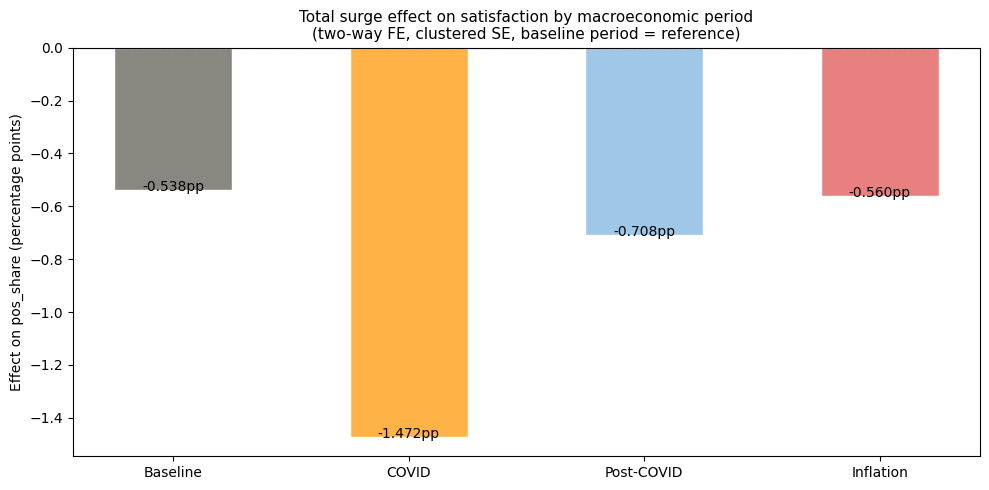

In [26]:
periods      = ['Baseline', 'COVID', 'Post-COVID', 'Inflation']
surge_effects = [
    results_summary['M3']['surge_baseline']   * 100,
    results_summary['M3']['surge_covid']      * 100,
    results_summary['M3']['surge_post_covid'] * 100,
    results_summary['M3']['surge_inflation']  * 100,
]

colors = ['#888780', '#FFB347', '#9FC8E8', '#E88080']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(periods, surge_effects, color=colors, edgecolor='white', width=0.5)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')

for bar, val in zip(bars, surge_effects):
    ypos = bar.get_height() + 0.001 if val >= 0 else bar.get_height() - 0.003
    ax.text(bar.get_x() + bar.get_width()/2, ypos,
            f'{val:.3f}pp', ha='center', fontsize=10)

ax.set_title('Total surge effect on satisfaction by macroeconomic period\n'
             '(two-way FE, clustered SE, baseline period = reference)', fontsize=11)
ax.set_ylabel('Effect on pos_share (percentage points)')
plt.tight_layout()
plt.savefig('m3_moderation_by_period.png', dpi=150, bbox_inches='tight')
plt.show()

Review surges on Steam reduce player satisfaction within the same game, contradicting the descriptive positive association driven by selection bias. This negative effect is robust across all detection specifications and filter thresholds.

Medium surges show the largest satisfaction decreases (−0.88pp), with partial recovery at large surges (−0.48pp) before renewed decline at extreme surges (−0.78pp). The mechanism driving this non-monotonic pattern is not directly identifiable from the current data and warrants further investigation. One possible explanation is that large surges are more likely to be driven by genuinely significant game events whose quality signal partially offsets the composition dilution effect. However, without data on the specific causes of individual surges, this interpretation remains speculative.

Macroeconomic context matters — COVID lockdowns nearly tripled the negative effect, likely because the rapid expansion of the gaming audience produced more extreme composition shifts than in normal market conditions.